# Multi-CN BCI — Batch QC Notebook

Mirror of `explore_carl_copy.ipynb` for the geometric-mean ensemble BCI experiment.

**Shift+Enter through all cells.**  
Cell 2 auto-discovers every (raw, processed) pair in `/data/` and picks the best  
BCI stem automatically. Cell 3 loops and writes PNGs to `/results/figures/`.

The only user config is in **Cell 1**: `TRIAL_START`, `CN_SMOOTH`, and the optional  
`CN_S2P_INDICES` override (needed only if auto-detection of suite2p ROI indices fails).  
Subject, date, stem, and N_CNs are all auto-detected.


In [32]:
import os, json, subprocess, re, sys, logging, traceback, warnings
import numpy as np
from pathlib import Path

sys.path.insert(0, "/code")
import extract_scanimage_metadata
import data_dict_create_module_bruker as ddc
import bonsai_npy_threshold_calculator_multiCN as multiCN_calc

%matplotlib inline
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
import matplotlib.pyplot as plt

# ── USER CONFIG ───────────────────────────────────────────────────────────────
TRIAL_START    = 40    # skip first N trials (early PMT artefacts); 0 = all
CN_SMOOTH      = 5     # heatmap smoothing window (trials); 0 = off
CN_S2P_INDICES = None  # list of 0-based s2p ROI indices, or None to auto-detect
# ─────────────────────────────────────────────────────────────────────────────


def find_pair_in_data(subject: str, date: str):
    """Return (raw_path, proc_path, proc_root) for the given subject+date."""
    asset_prefix = f"single-plane-ophys_{subject}_{date}_"
    attached = sorted(Path("/data").iterdir())
    raws  = [p for p in attached
             if p.name.startswith(asset_prefix) and "_processed_" not in p.name]
    procs = [p for p in attached
             if p not in raws and subject in p.name and date in p.name]
    if not raws:
        raise RuntimeError(f"No raw asset for {subject}/{date}. "
                           f"Attached: {[p.name for p in attached]}")
    if len(raws) > 1:
        raise RuntimeError(f"Multiple raw assets for {subject}/{date}: "
                           f"{[r.name for r in raws]}")
    raw = raws[0]
    if not procs:
        raise RuntimeError(f"No processed asset for {subject}/{date}")
    def _ts(p):
        m = re.search(r"_processed_(\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2})", p.name)
        return m.group(1) if m else ""
    proc = sorted(procs, key=_ts, reverse=True)[0]
    if (proc / "extraction").is_dir():
        proc_root = proc
    else:
        candidates = [c for c in proc.iterdir()
                      if c.is_dir() and (c / "extraction").is_dir()]
        if not candidates:
            raise RuntimeError(f"No extraction/ inside {proc.name}")
        proc_root = candidates[0]
    return raw, proc, proc_root


def _best_bci_stem(proc_root):
    """Pick the bci stem with the most trial files (e.g. bci2 over bci)."""
    trial_json = proc_root / "motion_correction" / "trial_locations.json"
    if not trial_json.exists():
        return "bci"
    with open(trial_json) as f:
        trial_locs = json.load(f)
    stem_counts = {}
    for name in trial_locs:
        parts = name.rsplit("_", 1)
        if len(parts) == 2:
            stem = parts[0]
            if re.match(r"bci\d*$", stem):
                stem_counts[stem] = stem_counts.get(stem, 0) + 1
    if not stem_counts:
        return "bci"
    best = max(stem_counts, key=stem_counts.get)
    if best != "bci":
        print(f"  {best!r} selected over 'bci' ({stem_counts})")
    return best


def process_session_multiCN(subject: str, date: str, target_stem: str):
    import importlib
    importlib.reload(multiCN_calc)
    """Build workspace, run ddc.main(), run multiCN QC figure, save PNGs."""
    session_tag  = f"{subject}_{date}_{target_stem}"
    workspace    = Path(f"/scratch/{session_tag}")
    pophys       = workspace / "pophys"
    figures_dir  = Path("/results") / "figures"
    figures_dir.mkdir(parents=True, exist_ok=True)

    raw, proc, proc_root = find_pair_in_data(subject, date)
    extraction = proc_root / "extraction"
    mc         = proc_root / "motion_correction"
    print(f"  raw:  {raw.name}")
    print(f"  proc: {proc.name}")

    # Resolve target epoch
    with open(mc / "epoch_locations.json") as f:
        epoch_locations = json.load(f)
    with open(mc / "trial_locations.json") as f:
        trial_locations = json.load(f)

    if target_stem not in epoch_locations:
        base = target_stem.rstrip("0123456789") or target_stem
        candidates = sorted(k for k in epoch_locations if base in k)
        if not candidates:
            raise RuntimeError(f"Epoch {target_stem!r} not found. "
                               f"Available: {list(epoch_locations)}")
        resolved = base if base in epoch_locations else candidates[0]
        print(f"  NOTE: {target_stem!r} not in epochs; using {resolved!r}")
        target_stem = resolved

    target_start, target_end = epoch_locations[target_stem]

    # Build workspace
    subprocess.run(["rm", "-rf", str(workspace)], check=False)
    pophys.mkdir(parents=True)

    # Behavior: symlink everything; repair SoftwareEvents NDJSON truncation
    behavior_src = raw / "behavior"
    behavior_dst = workspace / "behavior"
    for src_path in behavior_src.rglob("*"):
        rel      = src_path.relative_to(behavior_src)
        dst_path = behavior_dst / rel
        if src_path.is_dir():
            dst_path.mkdir(parents=True, exist_ok=True)
        elif src_path.suffix == ".json" and rel.parts[0] == "SoftwareEvents":
            lines = src_path.read_text(errors="replace").splitlines()
            good, skipped = [], 0
            for line in lines:
                line = line.strip()
                if not line:
                    continue
                try:
                    json.loads(line)
                    good.append(line)
                except json.JSONDecodeError:
                    skipped += 1
            if skipped:
                print(f"  {rel}: dropped {skipped} malformed line(s)")
            dst_path.write_text("\n".join(good) + "\n")
        else:
            if not dst_path.exists():
                dst_path.symlink_to(src_path)

    target_tifs = sorted(
        name for name, (s, e) in trial_locations.items()
        if name.startswith(f"{target_stem}_") and s >= target_start and e <= target_end
    )
    frames_per_file = [trial_locations[n][1] - trial_locations[n][0] + 1
                       for n in target_tifs]
    print(f"  {len(target_tifs)} TIFFs ({sum(frames_per_file)} frames)")

    # Symlink sidecar files (csv, mat) — includes *_threshold_N.mat for multiCN_calc
    for f in (raw / "pophys").iterdir():
        if (f.is_file() and f.suffix not in (".tif", ".stim")
                and f.name.startswith(f"{target_stem}_")):
            tgt = pophys / f.name
            if not tgt.exists():
                tgt.symlink_to(f)

    bci_dir = pophys / "suite2p_BCI" / "plane0"
    bci_dir.mkdir(parents=True)

    has_spont = "spont_pre" in epoch_locations
    if has_spont:
        s_start, s_end = epoch_locations["spont_pre"]
        spont_dir = pophys / "suite2p_spont_pre" / "plane0"
        spont_dir.mkdir(parents=True)
        s_slice = slice(s_start, s_end + 1)

    frame_slice = slice(target_start, target_end + 1)
    for fname in ["F", "Fneu", "spks"]:
        src = extraction / f"{fname}.npy"
        if src.exists():
            arr = np.load(src, mmap_mode="r")
            np.save(bci_dir / f"{fname}.npy", arr[:, frame_slice])
            if has_spont:
                np.save(spont_dir / f"{fname}.npy", arr[:, s_slice])
            del arr

    for fname in ["stat.npy", "iscell.npy"]:
        src = extraction / fname
        if src.exists():
            (bci_dir / fname).symlink_to(src)
            if has_spont:
                (spont_dir / fname).symlink_to(src)

    ops = np.load(extraction / "ops.npy", allow_pickle=True).tolist()
    ops["frames_per_file"] = frames_per_file
    np.save(bci_dir / "ops.npy", ops)

    first_tif = raw / "pophys" / target_tifs[0]
    siHeader  = extract_scanimage_metadata.extract_scanimage_metadata(str(first_tif))
    siHeader["siBase"]      = {0: target_stem, 1: "", 2: "spont_pre"}
    siHeader["savefolders"] = {0: target_stem, 1: "spont", 2: "spont_post",
                               3: "spont_pre", 4: "spont_post"}
    np.save(bci_dir / "siHeader.npy", siHeader)

    # ddc.main
    folder = str(pophys) + "/"
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        data = ddc.main(folder)
    m = re.match(r"single-plane-ophys_(\w+)_(\d{4}-\d{2}-\d{2})_", raw.name)
    if m:
        data["mouse"]   = m.group(1)
        data["session"] = m.group(2)

    # multiCN QC figure
    try:
        figs = multiCN_calc.run(
            folder, data,
            trial_start    = TRIAL_START,
            cn_smooth      = CN_SMOOTH,
            cn_s2p_indices = CN_S2P_INDICES,   # None = auto-detect
        )
    except Exception as e:
        print(f"  multiCN_calc failed: {e}")
        figs = []
    finally:
        del data

    # 2/98 percentile clip on all heatmap images (same as single-CN notebook)
    for fig in figs:
        for ax in fig.get_axes():
            for im in ax.get_images():
                arr = im.get_array()
                if arr is None:
                    continue
                arr = np.asarray(arr)
                if arr.ndim == 2:
                    im.set_clim(np.nanpercentile(arr, 2),
                                np.nanpercentile(arr, 98))
        fig.canvas.draw()

    saved = 0
    for i, fig in enumerate(figs):
        out = figures_dir / f"{session_tag}_fig_{i:02d}.png"
        fig.savefig(out, dpi=150, bbox_inches="tight")
        saved += 1
    for fig in figs:
        plt.close(fig)

    return figures_dir / f"{session_tag}_fig_00.png", saved


In [33]:
from datetime import date as _date, timedelta as _timedelta

# Only sessions within the last 2 days by default.
# Set DATE_FILTER_DAYS = None to include all attached dates.
DATE_FILTER_DAYS = {
    _date.today().strftime("%Y-%m-%d"),
    (_date.today() - _timedelta(days=1)).strftime("%Y-%m-%d"),
}

attached = sorted(Path("/data").iterdir())
print(f"Attached assets in /data ({len(attached)}):")
for p in attached:
    print(f"  {p.name}")

raws_all = [p for p in attached
            if p.name.startswith("single-plane-ophys_") and "_processed_" not in p.name]
auto_targets: list[tuple[str, str, str]] = []
for raw in raws_all:
    m = re.match(r"single-plane-ophys_(\w+)_(\d{4}-\d{2}-\d{2})_", raw.name)
    if not m:
        continue
    subject, date = m.group(1), m.group(2)
    if DATE_FILTER_DAYS is not None and date not in DATE_FILTER_DAYS:
        continue
    has_proc = any(
        "_processed_" in p.name and subject in p.name and date in p.name
        for p in attached
    )
    if has_proc:
        try:
            _, _, proc_root = find_pair_in_data(subject, date)
            stem = _best_bci_stem(proc_root)
        except Exception:
            stem = "bci"
        auto_targets.append((subject, date, stem))

# === Edit here to override ===
TARGETS = auto_targets   # default: process today's + yesterday's sessions
# Common overrides:
#   DATE_FILTER_DAYS = None                                      # all dates
#   TARGETS = [("824946", "2026-06-11", "bci2")]                 # specific session
# =============================

print(f"\nDate filter: {DATE_FILTER_DAYS or 'none (all dates)'}")
print(f"Will process {len(TARGETS)} session(s):")
for sub, dt, stem in TARGETS:
    print(f"  {sub}  {dt}  stem={stem}")


Attached assets in /data (2):
  single-plane-ophys_824946_2026-06-11_16-15-01
  single-plane-ophys_824946_2026-06-11_16-15-01_processed_2026-06-12_05-10-08

Date filter: {'2026-06-11', '2026-06-12'}
Will process 1 session(s):
  824946  2026-06-11  stem=bci



  824946  2026-06-11  bci
  raw:  single-plane-ophys_824946_2026-06-11_16-15-01
  proc: single-plane-ophys_824946_2026-06-11_16-15-01_processed_2026-06-12_05-10-08
  177 TIFFs (120599 frames)
[bci] keeping 2 iscell==0 ROI(s) within 10 px of CN: [453, 592]
No suite2p_ch1/plane0 folder found — skipping ch1 data.
Loading spont_pre data from /scratch/824946_2026-06-11_bci/pophys/suite2p_spont_pre
[bonsai] 178 Bonsai trials, 177 SI files, 177 matched
[MAIN] Non-photostim data saved as pickle: /scratch/824946_2026-06-11_bci/pophys/data_main_scratch_824946_2026-06-11_bci_BCI.npy
[MAIN] Non-photostim data saved as HDF5:   /scratch/824946_2026-06-11_bci/pophys/data_main_scratch_824946_2026-06-11_bci_BCI.h5
  Threshold files: 175 total → 12 distinct M value(s)
  10 CNs (auto-detected)  |  12 threshold updates  |  177 trials  |  trial_start=40
  CN s2p indices (auto): [ 151  452  491  324 1188  415]  ← verify with inspection cell
  Normalisation: using suite2p spont_pre (5th / 80th pct).
  multi

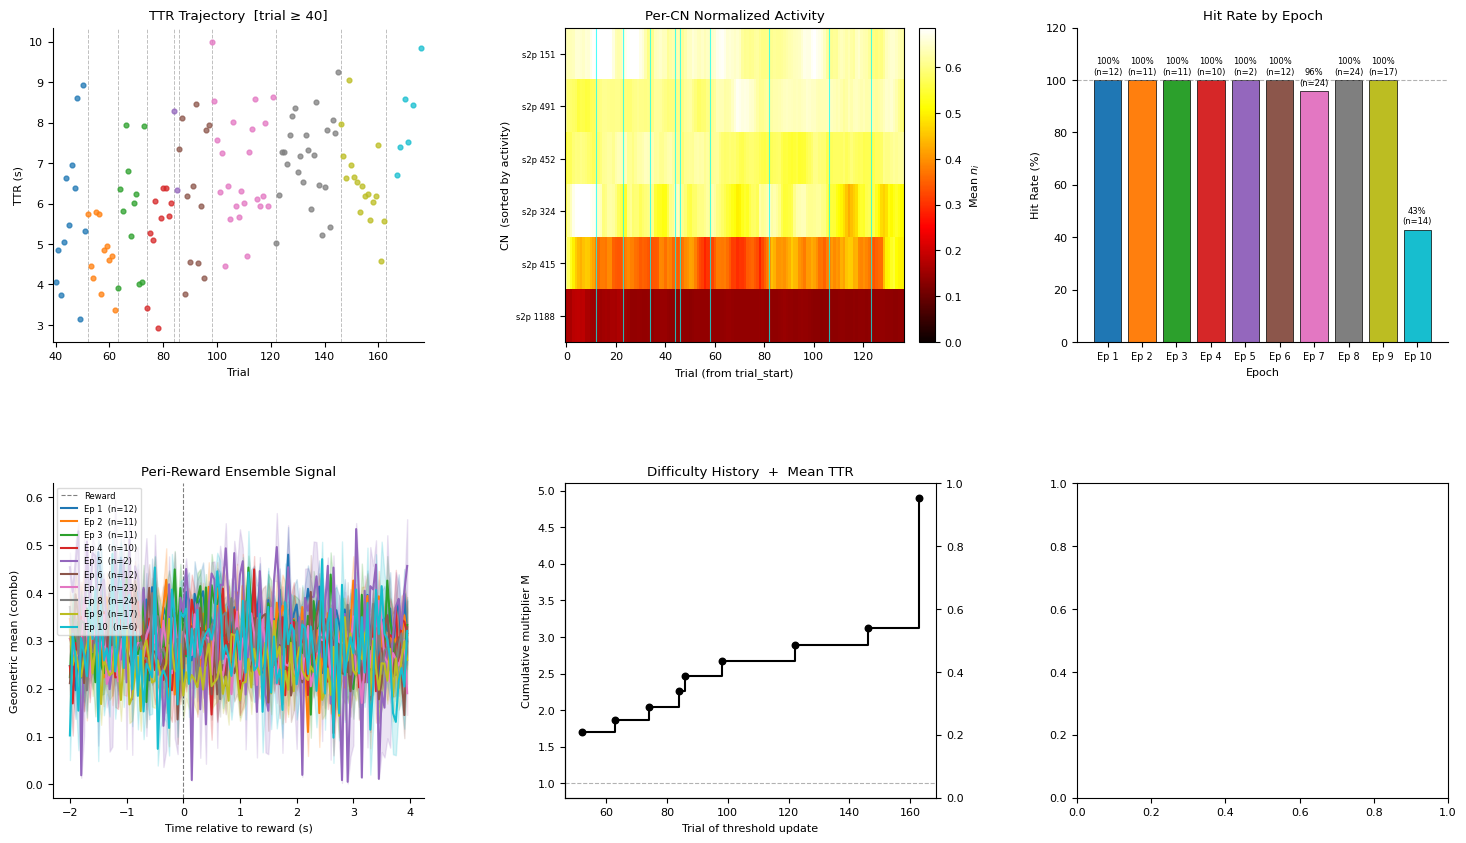

In [34]:
import time, gc

FORCE = False   # set True to re-run sessions that already have a PNG

completed, skipped, failed = [], [], []
t0          = time.time()
figures_dir = Path("/results") / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

for subject, date, stem in TARGETS:
    session_tag  = f"{subject}_{date}_{stem}"
    expected_png = figures_dir / f"{session_tag}_fig_00.png"

    if expected_png.exists() and not FORCE:
        print(f"  SKIP  {subject}  {date}  {stem}  (PNG exists)")
        skipped.append({"subject": subject, "date": date, "stem": stem})
        continue

    print(f"\n{'='*70}")
    print(f"  {subject}  {date}  {stem}")
    print(f"{'='*70}")
    t_session = time.time()
    try:
        results_path, n_figs = process_session_multiCN(subject, date, stem)
        dt = time.time() - t_session
        completed.append({"subject": subject, "date": date, "stem": stem,
                          "n_figures": n_figs, "elapsed_sec": round(dt, 1)})
        print(f"  -> {results_path}  ({n_figs} figs, {dt:.0f} sec)")
    except Exception as e:
        dt = time.time() - t_session
        failed.append({"subject": subject, "date": date, "stem": stem,
                       "error": str(e), "elapsed_sec": round(dt, 1)})
        print(f"  FAILED: {e}")
        traceback.print_exc()
    gc.collect()

t_total = time.time() - t0
print(f"\n{'='*70}")
print(f"Done in {t_total:.0f} sec.")
print(f"  completed: {len(completed)}")
print(f"  skipped:   {len(skipped)}  (set FORCE=True to re-run)")
print(f"  failed:    {len(failed)}")
print(f"{'='*70}")
if failed:
    print("Failures:")
    for f in failed:
        print(f"  {f['subject']} {f['date']} {f['stem']}: {f['error']}")

with open(Path("/results") / "batch_summary.json", "w") as fh:
    json.dump({"completed": completed, "skipped": skipped, "failed": failed,
               "total_sec": round(t_total, 1)}, fh, indent=2)


In [35]:
fig_dir = Path("/results") / "figures"
from matplotlib.image import imread

for subject, date, stem in TARGETS:
    session_tag = f"{subject}_{date}_{stem}"
    png = fig_dir / f"{session_tag}_fig_00.png"
    if png.exists():
        img = imread(str(png))
        fig, ax = plt.subplots(figsize=(14, 8))
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(session_tag, fontsize=10)
        plt.tight_layout()
        plt.show()
    else:
        print(f"  No fig_00 for {session_tag}")


  No fig_00 for 824946_2026-06-11_bci
